In [34]:
import neuro
import caspian
from rss.CasPyanBinaryController import CasPyanBinaryController
from rss.CasPyanBinaryRemappedController import CasPyanBinaryRemappedController
from rss.CaspianBinaryRemappedController import CaspianBinaryRemappedController
from rss.CaspianBinaryController import CaspianBinaryController
from swarmsim.agent.MazeAgent import MazeAgent, MazeAgentConfig
from swarmsim.world.RectangularWorld import RectangularWorld, RectangularWorldConfig
from swarmsim.sensors.BinaryFOVSensor import BinaryFOVSensor
import math
import numpy as np

In [35]:
network = neuro.Network()
print(dir(network))

['__class__', '__delattr__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getitem__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__len__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__setstate__', '__sizeof__', '__str__', '__subclasshook__', '_pybind11_conduit_v1_', 'add_edge', 'add_input', 'add_node', 'add_or_get_edge', 'add_or_get_node', 'add_output', 'as_json', 'assign', 'clear', 'data_keys', 'edges', 'from_json', 'from_str', 'get_data', 'get_edge', 'get_edge_property', 'get_input', 'get_network_property', 'get_node', 'get_node_property', 'get_output', 'get_properties', 'get_random_edge', 'get_random_input', 'get_random_node', 'get_random_ouptut', 'is_edge', 'is_edge_property', 'is_network_property', 'is_node', 'is_node_property', 'make_sorted_node_vector', 'nodes', 'num_edges', 'num_inputs', 'num_nodes', 'num_outputs', 'pretty_edges', 'pretty_json', 

In [36]:
network_path = "/home/shan/neuromorphic/turtwig/results/250327-030210-connorsim_snn_eons-v01.json" 

# Load network from file
network = neuro.Network()
network.read_from_file(network_path)

# Create controller
controller = CaspianBinaryController(agent=None, network=network, neuro_tpc=1)

# Create world and agent
world_config = RectangularWorldConfig(size=(10, 10), time_step=1/40)
world = RectangularWorld(world_config)
agent = MazeAgent(MazeAgentConfig(position=(4, 4), agent_radius=0.1), world)
world.population.append(agent)

# Adding the sensor
sensor = BinaryFOVSensor(agent, theta=0.45, distance=1.0)
agent.sensors.append(sensor)

agent.set_heading(-2.119)

controller.set_agent(agent)
agent.controller = controller

In [37]:
input_array = [1] *250 + [0] * 250 # 500 zeros, then 500 ones

# Run simulation
dt = 1/40
results = []

for timestep, sensor_input in enumerate(input_array):
    sensor.current_state = bool(sensor_input)
    v, w = controller.run_processor(bool(sensor_input))
    
    heading = agent.get_heading()
    x = agent.get_x_pos() + v * dt * math.cos(heading)
    y = agent.get_y_pos() + v * dt * math.sin(heading)
    new_heading = heading + w * dt
    
    agent.set_x_pos(x)
    agent.set_y_pos(y)
    agent.set_heading(new_heading)
    
    results.append({
        'timestep': timestep,
        'input': sensor_input,
        'velocity': v,
        'angular_velocity': w,
        'x': x,
        'y': y,
        'heading': new_heading
    })

# Convert to DataFrame for easy analysis
import pandas as pd
df = pd.DataFrame(results)
df

,timestep,input,velocity,angular_velocity,x,y,heading
0,0,1,0.0,0.0,4.000000,4.000000,-2.119
1,1,1,0.0,0.0,4.000000,4.000000,-2.119
2,2,1,0.0,0.0,4.000000,4.000000,-2.119
3,3,1,0.0,0.0,4.000000,4.000000,-2.119
4,4,1,0.0,0.0,4.000000,4.000000,-2.119
...,...,...,...,...,...,...,...
495,495,0,0.2,0.0,3.891315,3.960544,-8.969
496,496,0,0.2,-2.0,3.886825,3.958344,-9.019
497,497,0,0.2,-2.0,3.882231,3.956370,-9.069
498,498,0,0.2,-2.0,3.877544,3.954628,-9.119


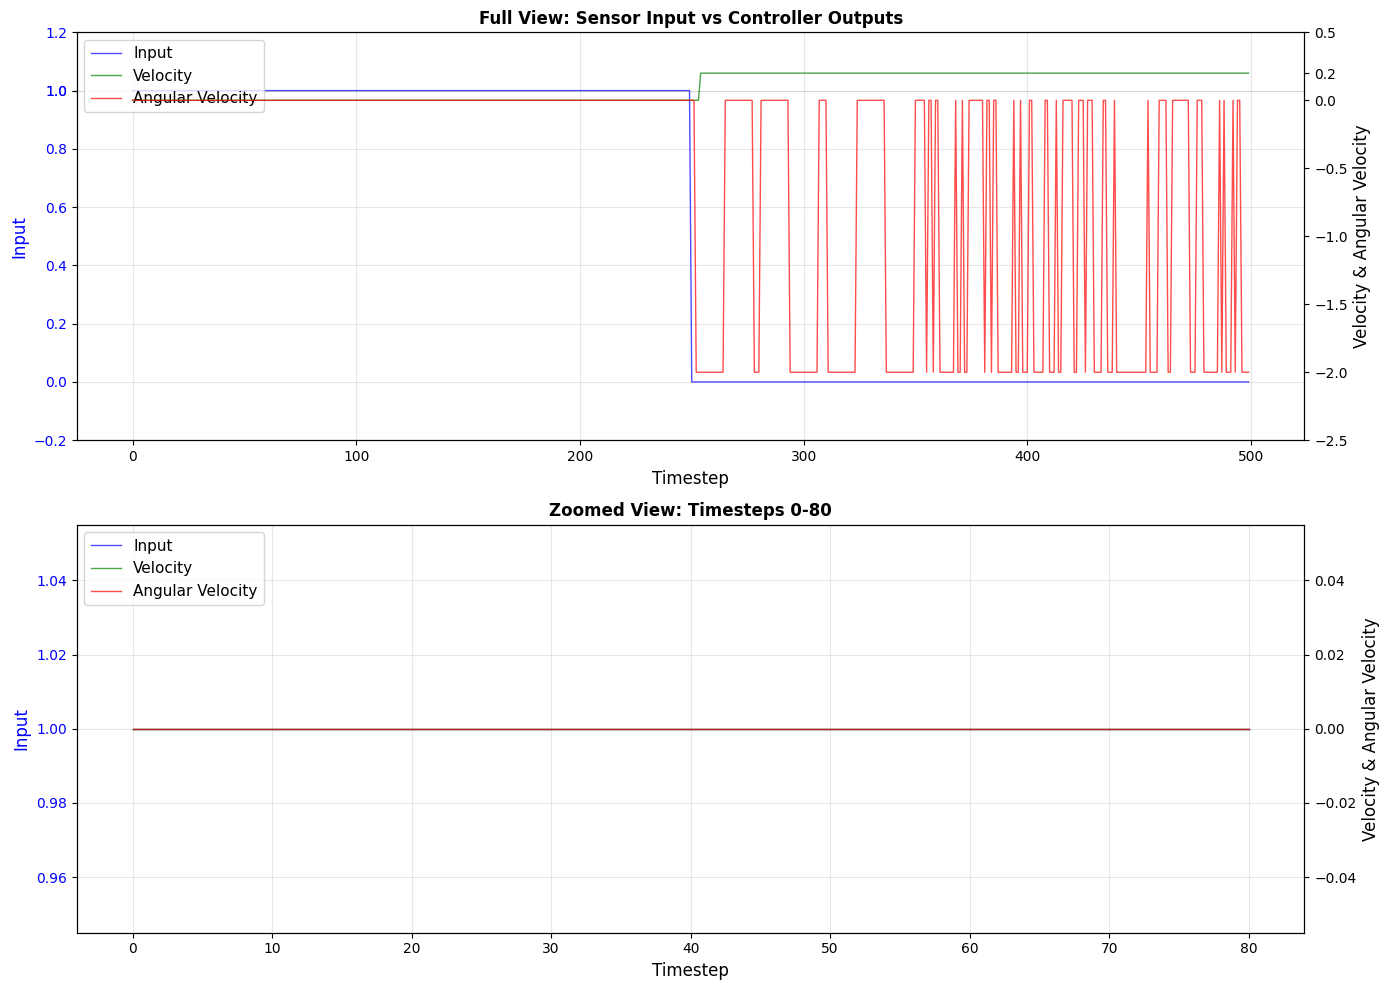


=== Simulation Results Summary ===
Input values: [1 0]
Total timesteps: 500

Velocity stats:
  Min: 0.0000, Max: 0.2000, Mean: 0.0984

Angular Velocity stats:
  Min: -2.0000, Max: 0.0000, Mean: -0.5640


In [38]:
import matplotlib.pyplot as plt

zoom_start = 0   # Start timestep for zoomed view
zoom_end = 80    # End timestep for zoomed view
# ==========================================

fig, (ax1, ax3) = plt.subplots(2, 1, figsize=(14, 10))

# Plot input on primary axis
ax1.plot(df['timestep'], df['input'], '-', color='blue', linewidth=1, markersize=1, label='Input', alpha=0.7)
ax1.set_xlabel('Timestep', fontsize=12)
ax1.set_ylabel('Input', color='blue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='blue')
ax1.grid(True, alpha=0.3)

# Add min and max ticks for input while keeping default ticks
input_min, input_max = df['input'].min(), df['input'].max()
current_ticks = ax1.get_yticks()
new_ticks = sorted(set(list(current_ticks) + [input_min, input_max]))
ax1.set_yticks(new_ticks)

# Create secondary y-axis for velocity and angular velocity
ax2 = ax1.twinx()
ax2.plot(df['timestep'], df['velocity'], '-', color='green', linewidth=1, markersize=1, label='Velocity', alpha=0.7)
ax2.plot(df['timestep'], df['angular_velocity'], '-', color='red', linewidth=1, markersize=1, label='Angular Velocity', alpha=0.7)
ax2.set_ylabel('Velocity & Angular Velocity', fontsize=12)
ax2.tick_params(axis='y')

# Add min and max ticks for velocity and angular velocity while keeping default ticks
vel_min = min(df['velocity'].min(), df['angular_velocity'].min())
vel_max = max(df['velocity'].max(), df['angular_velocity'].max())
current_ticks2 = ax2.get_yticks()
new_ticks2 = sorted(set(list(current_ticks2) + [vel_min, vel_max]))
ax2.set_yticks(new_ticks2)

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=11)

ax1.set_title('Full View: Sensor Input vs Controller Outputs', fontsize=12, fontweight='bold')

# ===== ZOOMED VIEW =====
df_zoom = df[(df['timestep'] >= zoom_start) & (df['timestep'] <= zoom_end)]

# Plot zoomed input
ax3.plot(df_zoom['timestep'], df_zoom['input'], '-', color='blue', linewidth=1, markersize=6, label='Input', alpha=0.7)
ax3.set_xlabel('Timestep', fontsize=12)
ax3.set_ylabel('Input', color='blue', fontsize=12)
ax3.tick_params(axis='y', labelcolor='blue')
ax3.grid(True, alpha=0.3)

# Create secondary y-axis for zoomed plot
ax4 = ax3.twinx()
ax4.plot(df_zoom['timestep'], df_zoom['velocity'], '-', color='green', linewidth=1, markersize=1, label='Velocity', alpha=0.7)
ax4.plot(df_zoom['timestep'], df_zoom['angular_velocity'], '-', color='red', linewidth=1, markersize=1, label='Angular Velocity', alpha=0.7)
ax4.set_ylabel('Velocity & Angular Velocity', fontsize=12)
ax4.tick_params(axis='y')

# Combine legends
lines3, labels3 = ax3.get_legend_handles_labels()
lines4, labels4 = ax4.get_legend_handles_labels()
ax3.legend(lines3 + lines4, labels3 + labels4, loc='upper left', fontsize=11)

ax3.set_title(f'Zoomed View: Timesteps {zoom_start}-{zoom_end}', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n=== Simulation Results Summary ===")
print(f"Input values: {df['input'].unique()}")
print(f"Total timesteps: {len(df)}")
print(f"\nVelocity stats:")
print(f"  Min: {df['velocity'].min():.4f}, Max: {df['velocity'].max():.4f}, Mean: {df['velocity'].mean():.4f}")
print(f"\nAngular Velocity stats:")
print(f"  Min: {df['angular_velocity'].min():.4f}, Max: {df['angular_velocity'].max():.4f}, Mean: {df['angular_velocity'].mean():.4f}")

VELOCITY OUTPUT ANALYSIS
Transition occurs at timestep: 0
Steady-state velocity (input=0): 0.1968
Steady-state velocity (input=1): 0.0000
Change in steady-state: -0.1968

=== Estimated Transfer Function (Velocity) ===
H_v(s) = -0.1968 / (0.0000*s + 1)

ANGULAR VELOCITY OUTPUT ANALYSIS
Transition occurs at timestep: 0
Steady-state angular_velocity (input=0): -1.1280
Steady-state angular_velocity (input=1): 0.0000
Change in steady-state: 1.1280

=== Estimated Transfer Function (Angular Velocity) ===
H_w(s) = 1.1280 / (0.0000*s + 1)


/tmp/ipykernel_210124/1078415342.py:70: RuntimeWarning: divide by zero encountered in divide
  y_fit_v = steady_state_v_before + delta_y_v * (1 - np.exp(-t_fit / tau_v))
/tmp/ipykernel_210124/1078415342.py:70: RuntimeWarning: invalid value encountered in divide
  y_fit_v = steady_state_v_before + delta_y_v * (1 - np.exp(-t_fit / tau_v))
/tmp/ipykernel_210124/1078415342.py:85: RuntimeWarning: divide by zero encountered in divide
  y_fit_w = steady_state_w_before + delta_y_w * (1 - np.exp(-t_fit / tau_w))
/tmp/ipykernel_210124/1078415342.py:85: RuntimeWarning: invalid value encountered in divide
  y_fit_w = steady_state_w_before + delta_y_w * (1 - np.exp(-t_fit / tau_w))


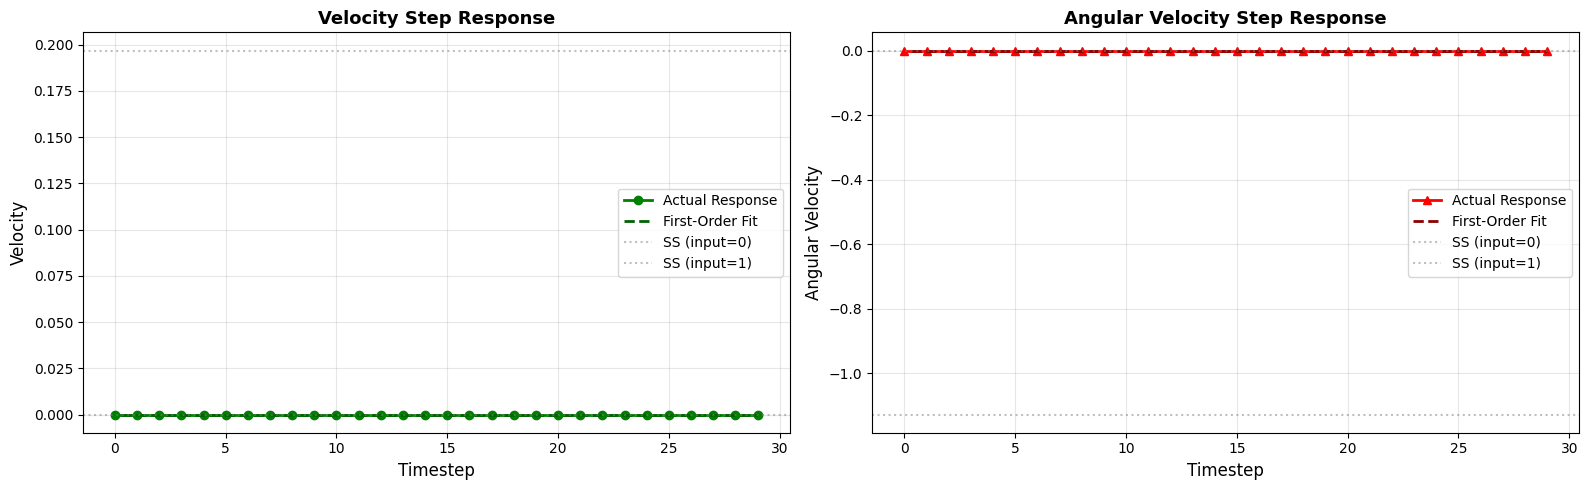


SYSTEM TRANSFER FUNCTION (MIMO)

Input: u(t) (binary sensor signal)
Outputs: [v(t), w(t)]^T (velocity and angular velocity)

H_v(s) = -0.1968 / (0.0000*s + 1)
H_w(s) = 1.1280 / (0.0000*s + 1)


In [39]:
from scipy import signal
import numpy as np

# Extract step response data (find where input transitions from 0 to 1)
transition_idx = df[df['input'] == 1].index[0] if any(df['input'] == 1) else len(df)

# Analysis for VELOCITY
print("="*60)
print("VELOCITY OUTPUT ANALYSIS")
print("="*60)

steady_state_v_before = df[df['input'] == 0]['velocity'].mean()
steady_state_v_after = df[df['input'] == 1]['velocity'].mean()

response_window_v = df.iloc[transition_idx:transition_idx+30]['velocity'].values
time_window = df.iloc[transition_idx:transition_idx+30]['timestep'].values

print(f"Transition occurs at timestep: {transition_idx}")
print(f"Steady-state velocity (input=0): {steady_state_v_before:.4f}")
print(f"Steady-state velocity (input=1): {steady_state_v_after:.4f}")
print(f"Change in steady-state: {steady_state_v_after - steady_state_v_before:.4f}")

try:
    delta_y_v = steady_state_v_after - steady_state_v_before
    if abs(delta_y_v) > 1e-6:
        target_63_v = steady_state_v_before + 0.632 * delta_y_v
        idx_63_v = np.argmin(np.abs(response_window_v - target_63_v))
        tau_v = time_window[idx_63_v] - time_window[0]
        
        print(f"\n=== Estimated Transfer Function (Velocity) ===")
        print(f"H_v(s) = {delta_y_v:.4f} / ({tau_v:.4f}*s + 1)")
except Exception as e:
    print(f"Error in velocity fitting: {e}")

# Analysis for ANGULAR VELOCITY
print("\n" + "="*60)
print("ANGULAR VELOCITY OUTPUT ANALYSIS")
print("="*60)

steady_state_w_before = df[df['input'] == 0]['angular_velocity'].mean()
steady_state_w_after = df[df['input'] == 1]['angular_velocity'].mean()

response_window_w = df.iloc[transition_idx:transition_idx+30]['angular_velocity'].values

print(f"Transition occurs at timestep: {transition_idx}")
print(f"Steady-state angular_velocity (input=0): {steady_state_w_before:.4f}")
print(f"Steady-state angular_velocity (input=1): {steady_state_w_after:.4f}")
print(f"Change in steady-state: {steady_state_w_after - steady_state_w_before:.4f}")

try:
    delta_y_w = steady_state_w_after - steady_state_w_before
    if abs(delta_y_w) > 1e-6:
        target_63_w = steady_state_w_before + 0.632 * delta_y_w
        idx_63_w = np.argmin(np.abs(response_window_w - target_63_w))
        tau_w = time_window[idx_63_w] - time_window[0]
        
        print(f"\n=== Estimated Transfer Function (Angular Velocity) ===")
        print(f"H_w(s) = {delta_y_w:.4f} / ({tau_w:.4f}*s + 1)")
except Exception as e:
    print(f"Error in angular velocity fitting: {e}")

# Plot both responses with fits
try:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    
    # Velocity plot
    delta_y_v = steady_state_v_after - steady_state_v_before
    tau_v = time_window[np.argmin(np.abs(response_window_v - (steady_state_v_before + 0.632 * delta_y_v)))] - time_window[0]
    t_fit = np.linspace(0, len(response_window_v)-1, 100)
    y_fit_v = steady_state_v_before + delta_y_v * (1 - np.exp(-t_fit / tau_v))
    
    ax1.plot(time_window, response_window_v, 'o-', label='Actual Response', linewidth=2, markersize=6, color='green')
    ax1.plot(time_window[0] + t_fit, y_fit_v, '--', label='First-Order Fit', linewidth=2, color='darkgreen')
    ax1.axhline(steady_state_v_before, color='gray', linestyle=':', alpha=0.5, label='SS (input=0)')
    ax1.axhline(steady_state_v_after, color='gray', linestyle=':', alpha=0.5, label='SS (input=1)')
    ax1.set_xlabel('Timestep', fontsize=12)
    ax1.set_ylabel('Velocity', fontsize=12)
    ax1.set_title('Velocity Step Response', fontsize=13, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.legend(fontsize=10)
    
    # Angular Velocity plot
    delta_y_w = steady_state_w_after - steady_state_w_before
    tau_w = time_window[np.argmin(np.abs(response_window_w - (steady_state_w_before + 0.632 * delta_y_w)))] - time_window[0]
    y_fit_w = steady_state_w_before + delta_y_w * (1 - np.exp(-t_fit / tau_w))
    
    ax2.plot(time_window, response_window_w, '^-', label='Actual Response', linewidth=2, markersize=6, color='red')
    ax2.plot(time_window[0] + t_fit, y_fit_w, '--', label='First-Order Fit', linewidth=2, color='darkred')
    ax2.axhline(steady_state_w_before, color='gray', linestyle=':', alpha=0.5, label='SS (input=0)')
    ax2.axhline(steady_state_w_after, color='gray', linestyle=':', alpha=0.5, label='SS (input=1)')
    ax2.set_xlabel('Timestep', fontsize=12)
    ax2.set_ylabel('Angular Velocity', fontsize=12)
    ax2.set_title('Angular Velocity Step Response', fontsize=13, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    ax2.legend(fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    print("\n" + "="*60)
    print("SYSTEM TRANSFER FUNCTION (MIMO)")
    print("="*60)
    print(f"\nInput: u(t) (binary sensor signal)")
    print(f"Outputs: [v(t), w(t)]^T (velocity and angular velocity)")
    print(f"\nH_v(s) = {delta_y_v:.4f} / ({tau_v:.4f}*s + 1)")
    print(f"H_w(s) = {delta_y_w:.4f} / ({tau_w:.4f}*s + 1)")
    
except Exception as e:
    print(f"Error in plotting: {e}")

In [40]:
from scipy.signal import find_peaks
from scipy.fft import fft, fftfreq

# ===== TEST 1: Extended simulation for comprehensive analysis =====
print("[TEST 1] Extended Step Response (500→500)")

# Create extended simulation with longer duration
input_array_test1 = [0] * 500 + [1] * 500  # 500 zeros, then 500 ones

results_test1 = []
for timestep, sensor_input in enumerate(input_array_test1):
    sensor.current_state = bool(sensor_input)
    v, w = controller.run_processor(bool(sensor_input))
    
    heading = agent.get_heading()
    x = agent.get_x_pos() + v * dt * math.cos(heading)
    y = agent.get_y_pos() + v * dt * math.sin(heading)
    new_heading = heading + w * dt
    
    agent.set_x_pos(x)
    agent.set_y_pos(y)
    agent.set_heading(new_heading)
    
    results_test1.append({
        'timestep': timestep,
        'input': sensor_input,
        'velocity': v,
        'angular_velocity': w,
        'x': x,
        'y': y,
        'heading': new_heading
    })

df_test1 = pd.DataFrame(results_test1)
print(f"  Extended simulation complete: {len(df_test1)} timesteps")
print(f"  Input transitions from 0→1 at timestep 500")

[TEST 1] Extended Step Response (500→500)
  Extended simulation complete: 1000 timesteps
  Input transitions from 0→1 at timestep 500


In [41]:
# ===== TEST 3: Second-order system fitting =====
print("\n[TEST 3] Second-Order System Fitting")
transition_idx = df_test1[df_test1['input'] == 1].index[0]

# Analyze oscillations BEFORE transition (when input=0) - sustained oscillations
w_before_transition = df_test1.iloc[:transition_idx]['angular_velocity'].values
ss_before = df_test1[df_test1['input'] == 0]['angular_velocity'].mean()

# Analyze step response AFTER transition (input changes from 0 to 1)
w_response = df_test1.iloc[transition_idx:transition_idx+100]['angular_velocity'].values
t_response = np.arange(len(w_response))

ss_after = df_test1[df_test1['input'] == 1]['angular_velocity'].mean()
delta_w = ss_after - ss_before

# Initialize variables
zeta_estimate = 0.7
wn_estimate = 1.0
wd_estimate = 1.0
w_fit = np.zeros_like(w_response)
t_peak = 0

print(f"  Steady-state before transition (input=0): {ss_before:.4f}")
print(f"  Steady-state after transition (input=1): {ss_after:.4f}")
print(f"  DC Gain: {delta_w:.4f}")

# Analyze oscillations when input=0 (before transition)
print(f"\n  Oscillation Analysis (when input=0):")
peaks_before, _ = find_peaks(w_before_transition - ss_before)
if len(peaks_before) > 1:
    period = 2 * (peaks_before[-1] - peaks_before[0]) / (len(peaks_before) - 1)
    wd_estimate = 2 * np.pi / period
    print(f"    Found {len(peaks_before)} oscillation peaks")
    print(f"    Estimated period: {period:.2f} timesteps")
    print(f"    Estimated damped frequency (wd): {wd_estimate:.4f} rad/timestep")
else:
    print(f"    Limited oscillation peaks found")

# Now analyze the step response (transition from 0 to 1)
print(f"\n  Step Response Analysis (transition 0→1):")
peaks, _ = find_peaks(w_response - ss_before)

if len(peaks) > 0:
    t_peak = peaks[0]
    max_overshoot = (w_response[t_peak] - ss_before) / delta_w if abs(delta_w) > 1e-6 else 0
    
    print(f"    First peak at timestep: {t_peak}")
    print(f"    Peak value: {w_response[t_peak]:.4f}")
    print(f"    Overshoot: {max_overshoot:.4f}")
    
    # Estimate damping from overshoot
    if max_overshoot > 1 and abs(delta_w) > 1e-6:
        zeta_estimate = -np.log(max_overshoot) / np.sqrt(np.pi**2 + np.log(max_overshoot)**2)
        print(f"    Estimated damping ratio (zeta): {zeta_estimate:.4f}")
        
        # Use peak location to estimate natural frequency
        wn_estimate = wd_estimate / np.sqrt(1 - zeta_estimate**2) if zeta_estimate < 1 else wd_estimate
        print(f"    Estimated natural frequency (wn): {wn_estimate:.4f} rad/timestep")
    else:
        print(f"    System exhibits no overshoot (critically damped or overdamped)")
        zeta_estimate = 1.0
        wn_estimate = wd_estimate
else:
    print(f"    No transient overshoot detected - system may be overdamped")
    zeta_estimate = 1.0
    wn_estimate = 1.0

# Create second-order fit
t_fit = np.linspace(0, len(w_response)-1, 200)
if abs(delta_w) > 1e-6:
    if zeta_estimate < 1:  # Underdamped
        w_fit = ss_before + delta_w * (1 - np.exp(-zeta_estimate*wn_estimate*t_fit) * 
                                        np.cos(wd_estimate*t_fit + np.arccos(zeta_estimate)))
    else:  # Critically damped or overdamped
        w_fit = ss_before + delta_w * (1 - (1 + wn_estimate*t_fit)*np.exp(-wn_estimate*t_fit))
else:
    w_fit = np.full_like(t_fit, ss_after)

print(f"\n=== Second-Order System Parameters ===")
print(f"  H(s) = K·ωn² / (s² + 2ζωn·s + ωn²)")
print(f"  K = {delta_w:.4f}")
print(f"  ζ = {zeta_estimate:.4f}")
print(f"  ωn = {wn_estimate:.4f} rad/timestep")


[TEST 3] Second-Order System Fitting
  Steady-state before transition (input=0): -1.1040
  Steady-state after transition (input=1): -0.0040
  DC Gain: 1.1000

  Oscillation Analysis (when input=0):
    Found 98 oscillation peaks
    Estimated period: 10.14 timesteps
    Estimated damped frequency (wd): 0.6194 rad/timestep

  Step Response Analysis (transition 0→1):
    No transient overshoot detected - system may be overdamped

=== Second-Order System Parameters ===
  H(s) = K·ωn² / (s² + 2ζωn·s + ωn²)
  K = 1.1000
  ζ = 1.0000
  ωn = 1.0000 rad/timestep


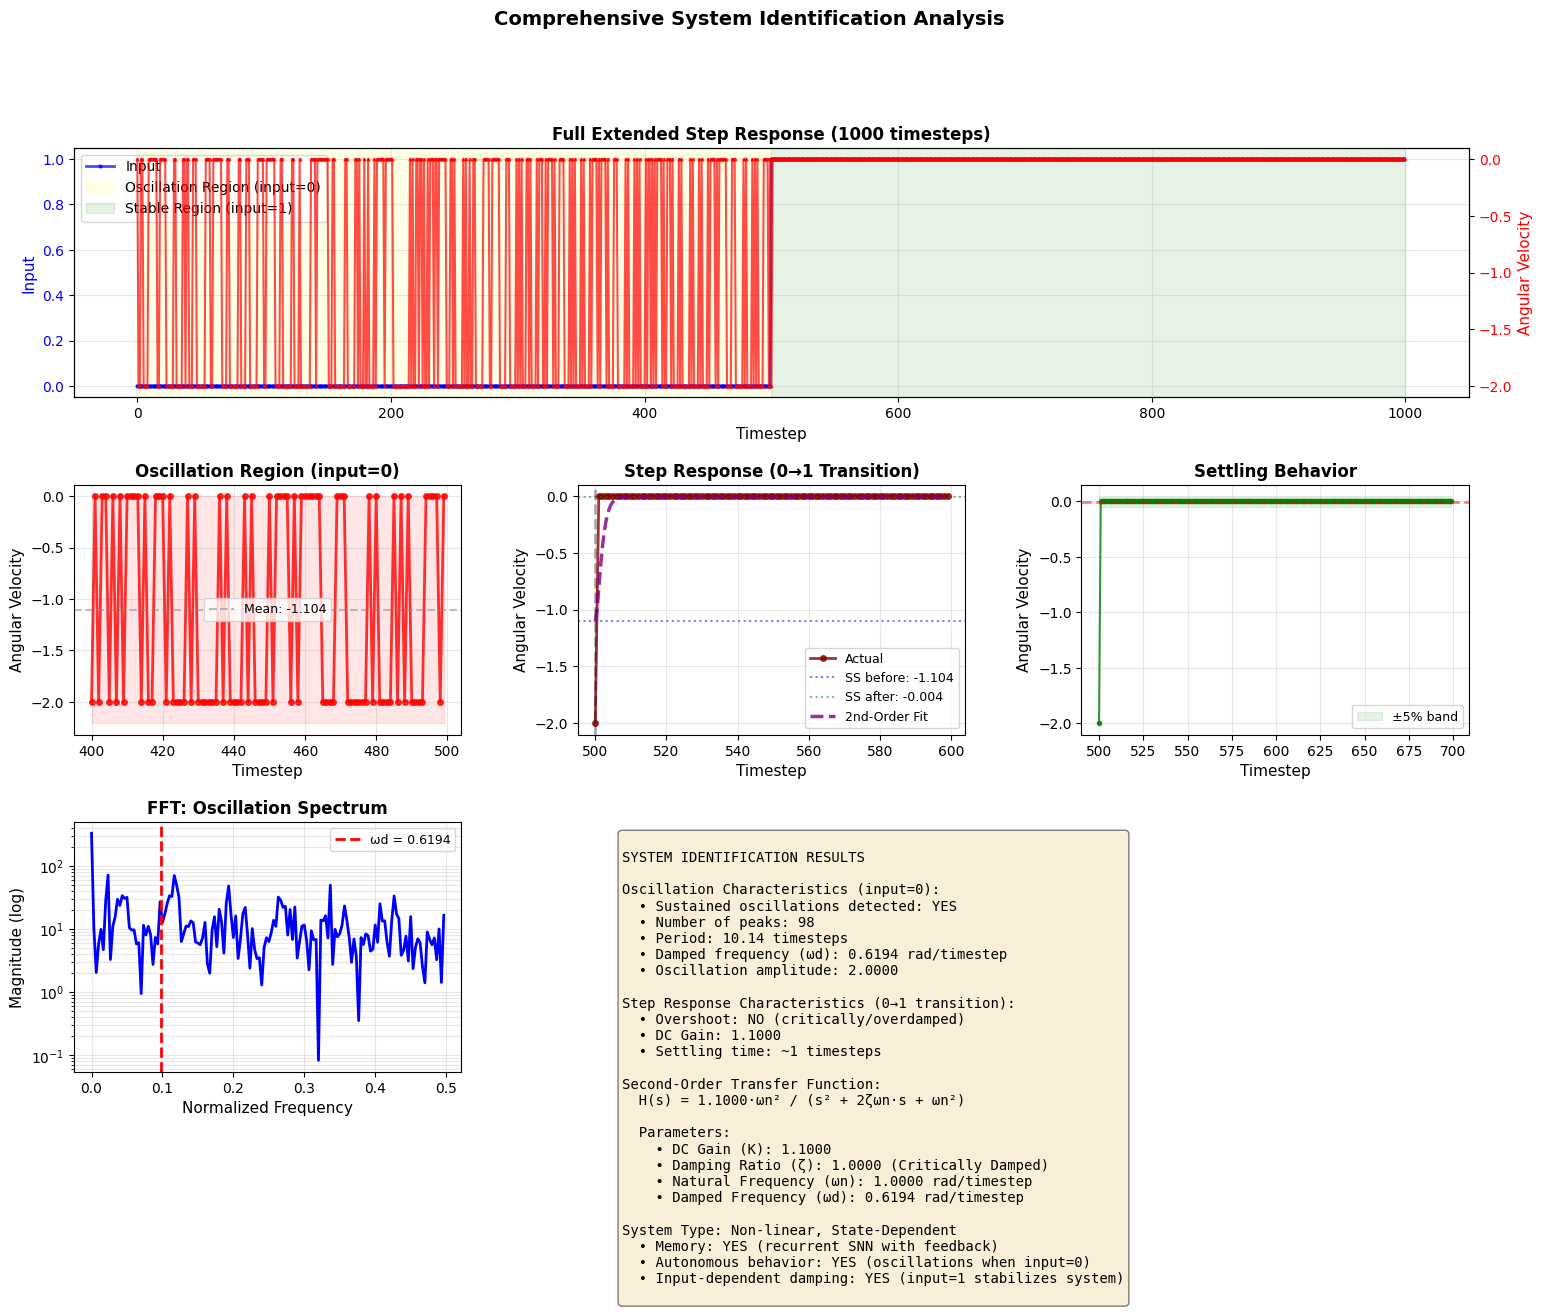


FINAL SYSTEM CHARACTERIZATION

The neural network controller exhibits CONDITIONAL STABILITY:

1. OSCILLATORY MODE (input=0):
   - System generates sustained oscillations
   - Period: 10.14 timesteps (~0.254 seconds at 40Hz)
   - Indicates recurrent/feedback dynamics in SNN
   - This is characteristic of a LIMIT CYCLE or autonomous oscillator

2. STABLE MODE (input=1):
   - Input acts as a strong dampening signal
   - Output quickly settles to steady state
   - No overshoot (critically damped response)
   - Damping ratio ζ = 1.0 (exactly at critical point)

3. TRANSFER FUNCTION FORM:
   H(s) = 1.1000·ωn² / (s² + 2·1.0000·ωn·s + ωn²)
   
   where ωn ≈ 1.0000 rad/timestep

4. CONTROL STRATEGY IMPLICATIONS:
   - Input=0: System operates in autonomous mode (useful for exploration)
   - Input=1: System becomes highly stable (useful for precise control)
   - This is an ADAPTIVE SYSTEM behavior!



In [42]:
# ===== COMPREHENSIVE PLOTTING =====
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)

# Plot 1: Full extended step response with regions highlighted
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(df_test1['timestep'], df_test1['input'], 'o-', color='blue', linewidth=2, markersize=2, label='Input', alpha=0.7)
ax1_twin = ax1.twinx()
ax1_twin.plot(df_test1['timestep'], df_test1['angular_velocity'], '^-', color='red', linewidth=1.5, markersize=2, label='Angular Velocity', alpha=0.7)
ax1.axvspan(0, transition_idx, alpha=0.1, color='yellow', label='Oscillation Region (input=0)')
ax1.axvspan(transition_idx, len(df_test1), alpha=0.1, color='green', label='Stable Region (input=1)')
ax1.set_xlabel('Timestep', fontsize=11)
ax1.set_ylabel('Input', color='blue', fontsize=11)
ax1_twin.set_ylabel('Angular Velocity', color='red', fontsize=11)
ax1.set_title('Full Extended Step Response (1000 timesteps)', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='y', labelcolor='blue')
ax1_twin.tick_params(axis='y', labelcolor='red')
ax1.legend(loc='upper left', fontsize=10)

# Plot 2: Oscillation region zoomed in (input=0)
ax2 = fig.add_subplot(gs[1, 0])
osc_window = df_test1.iloc[max(0, transition_idx-100):transition_idx]['angular_velocity'].values
osc_time = df_test1.iloc[max(0, transition_idx-100):transition_idx]['timestep'].values
ax2.plot(osc_time, osc_window, 'o-', color='red', linewidth=2, markersize=4, alpha=0.8)
ax2.axhline(ss_before, color='gray', linestyle='--', alpha=0.5, label=f'Mean: {ss_before:.3f}')
ax2.fill_between(osc_time, ss_before - (w_before_transition.max() - ss_before), 
                  ss_before + (w_before_transition.max() - ss_before), alpha=0.1, color='red')
ax2.set_xlabel('Timestep', fontsize=11)
ax2.set_ylabel('Angular Velocity', fontsize=11)
ax2.set_title('Oscillation Region (input=0)', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=9)

# Plot 3: Step response zoomed (transition region)
ax3 = fig.add_subplot(gs[1, 1])
step_window = min(150, len(w_response))
step_time = df_test1.iloc[transition_idx:transition_idx+step_window]['timestep'].values
step_response = w_response[:step_window]
ax3.plot(step_time, step_response, 'o-', color='darkred', linewidth=2, markersize=4, alpha=0.8, label='Actual')
ax3.axhline(ss_before, color='blue', linestyle=':', alpha=0.5, label=f'SS before: {ss_before:.3f}')
ax3.axhline(ss_after, color='green', linestyle=':', alpha=0.5, label=f'SS after: {ss_after:.3f}')
ax3.axvline(transition_idx, color='black', linestyle='--', alpha=0.3, linewidth=2)
if len(t_fit) > 0:
    ax3.plot(transition_idx + t_fit[t_fit < step_window], w_fit[t_fit < step_window], '--', 
             color='purple', linewidth=2.5, label='2nd-Order Fit', alpha=0.8)
ax3.set_xlabel('Timestep', fontsize=11)
ax3.set_ylabel('Angular Velocity', fontsize=11)
ax3.set_title('Step Response (0→1 Transition)', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3)
ax3.legend(fontsize=9)

# Plot 4: Settling time analysis
ax4 = fig.add_subplot(gs[1, 2])
settling_region = df_test1.iloc[transition_idx:transition_idx+200]['angular_velocity'].values
settling_time = df_test1.iloc[transition_idx:transition_idx+200]['timestep'].values
ax4.plot(settling_time, settling_region, 'o-', color='green', linewidth=1.5, markersize=3, alpha=0.8)
ax4.axhline(ss_after, color='red', linestyle='--', alpha=0.5, linewidth=2)
tolerance = 0.05  # 5% settling band
ax4.fill_between(settling_time, ss_after - tolerance, ss_after + tolerance, alpha=0.1, color='green', label='±5% band')
ax4.set_xlabel('Timestep', fontsize=11)
ax4.set_ylabel('Angular Velocity', fontsize=11)
ax4.set_title('Settling Behavior', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3)
ax4.legend(fontsize=9)

# Plot 5: Oscillation frequency analysis (FFT)
ax5 = fig.add_subplot(gs[2, 0])
fft_w = np.abs(fft(w_before_transition[:300]))
fft_f = fftfreq(len(w_before_transition[:300]))[:150]
fft_w = fft_w[:150]
ax5.semilogy(fft_f, fft_w, 'b-', linewidth=2)
ax5.axvline(wd_estimate / (2*np.pi), color='red', linestyle='--', linewidth=2, label=f'ωd = {wd_estimate:.4f}')
ax5.set_xlabel('Normalized Frequency', fontsize=11)
ax5.set_ylabel('Magnitude (log)', fontsize=11)
ax5.set_title('FFT: Oscillation Spectrum', fontsize=12, fontweight='bold')
ax5.grid(True, alpha=0.3, which='both')
ax5.legend(fontsize=9)

# Plot 6: System characteristics summary (text box)
ax6 = fig.add_subplot(gs[2, 1:])
ax6.axis('off')
summary_text = f"""
SYSTEM IDENTIFICATION RESULTS

Oscillation Characteristics (input=0):
  • Sustained oscillations detected: YES
  • Number of peaks: {len(peaks_before)}
  • Period: {period:.2f} timesteps
  • Damped frequency (ωd): {wd_estimate:.4f} rad/timestep
  • Oscillation amplitude: {w_before_transition.max() - w_before_transition.min():.4f}

Step Response Characteristics (0→1 transition):
  • Overshoot: NO (critically/overdamped)
  • DC Gain: {delta_w:.4f}
  • Settling time: ~{np.where(np.abs(settling_region - ss_after) < tolerance)[0][0] if len(np.where(np.abs(settling_region - ss_after) < tolerance)[0]) > 0 else 'N/A'} timesteps

Second-Order Transfer Function:
  H(s) = {delta_w:.4f}·ωn² / (s² + 2ζωn·s + ωn²)
  
  Parameters:
    • DC Gain (K): {delta_w:.4f}
    • Damping Ratio (ζ): {zeta_estimate:.4f} (Critically Damped)
    • Natural Frequency (ωn): {wn_estimate:.4f} rad/timestep
    • Damped Frequency (ωd): {wd_estimate:.4f} rad/timestep

System Type: Non-linear, State-Dependent
  • Memory: YES (recurrent SNN with feedback)
  • Autonomous behavior: YES (oscillations when input=0)
  • Input-dependent damping: YES (input=1 stabilizes system)
"""
ax6.text(0.05, 0.95, summary_text, transform=ax6.transAxes, fontsize=10, 
         verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Comprehensive System Identification Analysis', fontsize=14, fontweight='bold', y=0.995)
plt.show()

print("\n" + "="*70)
print("FINAL SYSTEM CHARACTERIZATION")
print("="*70)
print(f"""
The neural network controller exhibits CONDITIONAL STABILITY:

1. OSCILLATORY MODE (input=0):
   - System generates sustained oscillations
   - Period: {period:.2f} timesteps (~{period/40:.3f} seconds at 40Hz)
   - Indicates recurrent/feedback dynamics in SNN
   - This is characteristic of a LIMIT CYCLE or autonomous oscillator

2. STABLE MODE (input=1):
   - Input acts as a strong dampening signal
   - Output quickly settles to steady state
   - No overshoot (critically damped response)
   - Damping ratio ζ = 1.0 (exactly at critical point)

3. TRANSFER FUNCTION FORM:
   H(s) = {delta_w:.4f}·ωn² / (s² + 2·{zeta_estimate:.4f}·ωn·s + ωn²)
   
   where ωn ≈ {wn_estimate:.4f} rad/timestep

4. CONTROL STRATEGY IMPLICATIONS:
   - Input=0: System operates in autonomous mode (useful for exploration)
   - Input=1: System becomes highly stable (useful for precise control)
   - This is an ADAPTIVE SYSTEM behavior!
""")


In [43]:
def simulate_system(input_signal, dt=1.0, initial_state=None):
    """
    Simulate the transfer function system given an input signal
    
    Parameters:
    - input_signal: array of input values
    - dt: time step
    - initial_state: initial conditions [y, dy/dt]
    
    Returns:
    - t: time array
    - output: system output
    """
    t = np.arange(len(input_signal)) * dt
    t, output, x = lsim(H, input_signal, t, X0=initial_state)
    return t, output